In [1]:
from contrailstereo.validation import metrics as M

M.decomposition("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles.csv")

{'gate': 0.6,
 'n': 3609,
 'n_scenes': 66,
 'total': 0.6256394599064827,
 'within': 0.3912556091245997,
 'between': 0.4882046518834226}

In [2]:
M.map_tradeoff("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles.csv")


,gate,n_profiles,n_scenes,coverage,rmse_raw,rmse_corr_insample,bias
0,0.5,4341,74,0.807478,0.911918,0.812851,-0.413363
1,0.6,3609,66,0.671317,0.757331,0.625639,-0.426762
2,0.7,2453,49,0.456287,0.681942,0.535010,-0.422859


In [3]:
M.bias_correct_cv("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles.csv")

{'gate': 0.6,
 'n': 3609,
 'k': 5,
 'rmse_cv_corrected': 0.6460120129858732,
 'constant': -0.46921652247817414}

In [4]:
M.scene_summary("/Users/lewisclark/Documents/python_work/stereo/outputs/results.csv")

{'n_scenes': 148,
 'n_ok': 92,
 'n_data_invalid': 34,
 'yield_of_valid': np.float64(0.8070175438596491),
 'bias': -0.5176178954468265,
 'rmse_raw': 0.8194058793969646,
 'rmse_loo_corr': 0.6421950768681894,
 'ci95': (0.4118326141449495, 0.870496935604718),
 'verdicts': {'ok': 92,
  'coverage': 27,
  'low_r': 12,
  'no_data': 7,
  'low_edge': 5,
  'no_peak': 5}}

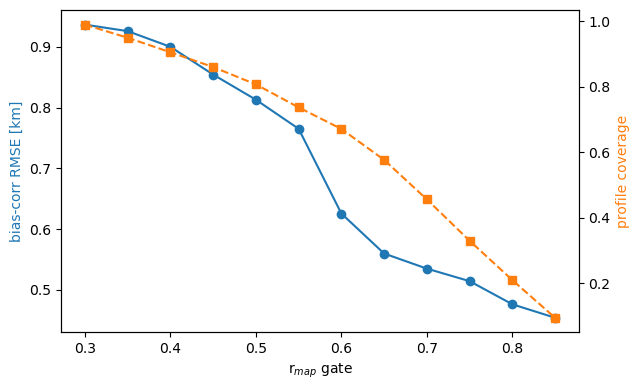

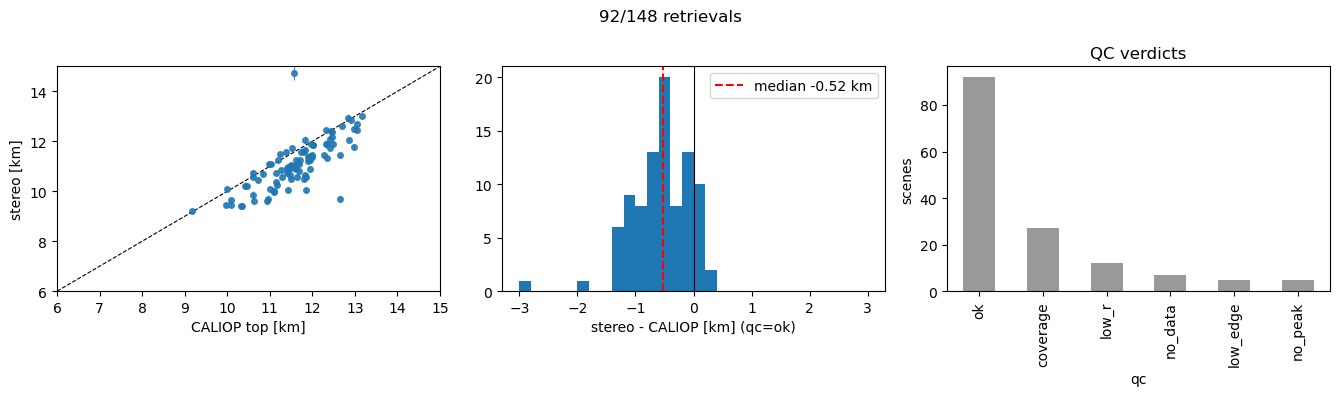

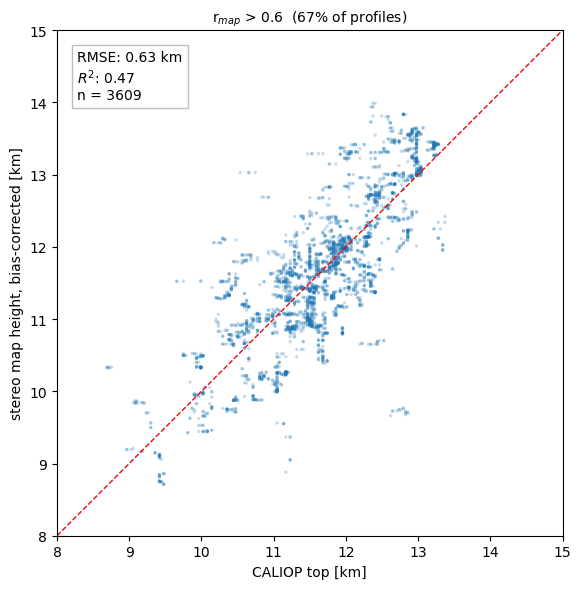

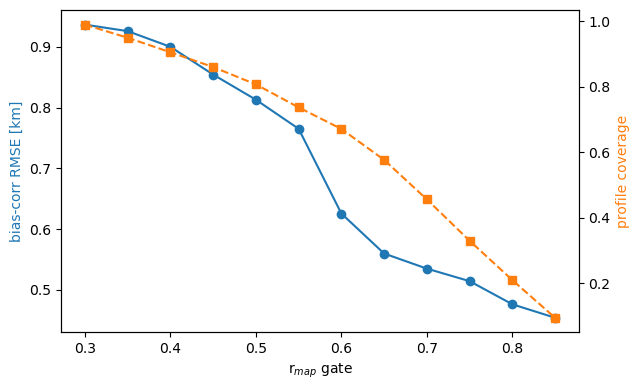

In [5]:
%matplotlib inline
from contrailstereo.vis import summary as VS, scene as VZ
from contrailstereo.validation import metrics as M
from contrailstereo.core.retrieve import run_scene

VS.run_summary("/Users/lewisclark/Documents/python_work/stereo/outputs/results.csv")
VS.map_scatter("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles.csv", gate=0.6)
VS.tradeoff_plot("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles.csv")

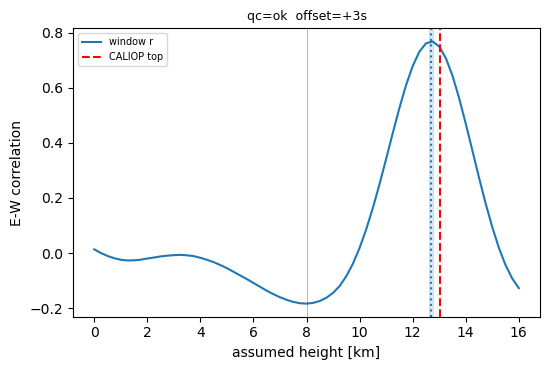

In [6]:
# per-scene, from a fixture (offline, instant):
import sys; sys.path.insert(0, "/Users/lewisclark/Documents/python_work/stereo/tests")     
from conftest import load_fixture_scene
rec, pr, extras = run_scene(load_fixture_scene(8))
VZ.curve_plot(extras, rec, truth_km=pr.top_km.median())
#VZ.map_panel(extras, pr, rec, 8)